In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import numpy as np
import pandas as pd
from IPython.display import FileLink

ALL_MODELS = {
    'GRU64': "model_GRU64_gradclip_RedPl",
    'LSTM64': "model_LSTM64_gradclip_RedPl",
    'LSTM32x2': "model_LSTM32x2_gradclip_RedPl_seq336_B128",
    'GRU32x2': "model_GRU32x2_gradclip_RedPl_seq336_B128",
    'LSTM64_1h': "model_1Hour_LSTM64_gradclip_RedPl_seq336",
    'GRU64_1h': "model_1Hour_GRU64_gradclip_RedPl_seq336",
    'LSTM32x2_1h': "model_1Hour_LSTM32x2_gradclip_RedPl_seq336_B128",
    'GRU32x2_1h': "model_1Hour_GRU32x2_gradclip_RedPl_seq336_B128"
}

In [2]:
#code to locate the working directory and list available files

print("Current working directory:", os.getcwd())

input_dir = '/kaggle/input/'

for root, dirs, files in os.walk(input_dir):
    print(f"Directory: {root}")
    print('---')




Current working directory: /kaggle/working
Directory: /kaggle/input/
---
Directory: /kaggle/input/energy-production
---
Directory: /kaggle/input/lstm-models
---
Directory: /kaggle/input/lstm-models/model_1Hour_GRU32x2_gradclip_RedPl_seq336_B128
---
Directory: /kaggle/input/lstm-models/model_LSTM64_gradclip_RedPl
---
Directory: /kaggle/input/lstm-models/model_1Hour_LSTM64_gradclip_RedPl_seq336
---
Directory: /kaggle/input/lstm-models/model_LSTM32x2_gradclip_RedPl_seq336_B128
---
Directory: /kaggle/input/lstm-models/model_GRU32x2_gradclip_RedPl_seq336_B128
---
Directory: /kaggle/input/lstm-models/model_1Hour_GRU64_gradclip_RedPl_seq336
---
Directory: /kaggle/input/lstm-models/model_GRU64_gradclip_RedPl
---
Directory: /kaggle/input/lstm-models/model_1Hour_LSTM32x2_gradclip_RedPl_seq336_B128
---


## Definitions

In [3]:
def make_history_path(model, base="/kaggle/input/lstm-models/", reg=ALL_MODELS):
    return f"{base}{reg[model]}/{reg[model]}_history.pkl"

def load_hist(path):
    if not os.path.exists(path):
        print(f" missing: {path}")
        return None
    with open(path, "rb") as f:
        return pickle.load(f)


def plot_lstm_gru_comparison(models, config,
                             color_lstm="#8C000F", color_gru="#008080"):
    # Load history data
    paths      = [make_history_path(m) for m in models]
    histories  = [load_hist(p) for p in paths]
    if any(h is None for h in histories):
        raise SystemExit("missing history file(s)")

    epochs = [range(1, len(h["loss"]) + 1) for h in histories]

    # Build pairs: always LSTM (even index) vs GRU (odd index)
    pairs = [(i, i+1) for i in range(0, len(models), 2)]

    # Determine row-wise y-axis limits
    row_limits = {}
    for row in range(config["rows"]):
        row_pairs = pairs[row * config["cols"]:(row + 1) * config["cols"]]
        row_vals = []
        for l_idx, g_idx in row_pairs:
            row_vals.extend(histories[l_idx]["val_mae"])
            row_vals.extend(histories[g_idx]["val_mae"])
        y_min, y_max = min(row_vals), max(row_vals)
        margin = 0.05 * (y_max - y_min)
        row_limits[row] = (y_min - margin, y_max + margin)

    # Plot
    plt.figure(figsize=(config["cols"]*8, config["rows"]*6))
    for i, (l_idx, g_idx) in enumerate(pairs):
        row = i // config["cols"]
        plt.subplot(config["rows"], config["cols"], i + 1)

        # LSTM
        val_l = histories[l_idx]["val_mae"]
        best_l = np.argmin(val_l) + 1
        plt.plot(epochs[l_idx], val_l, "-", color=color_lstm, lw=2,
                 label=f"{models[l_idx]} Validation Set")
        plt.axvline(best_l, color=color_lstm, ls="--")

        # GRU
        val_g = histories[g_idx]["val_mae"]
        best_g = np.argmin(val_g) + 1
        plt.plot(epochs[g_idx], val_g, "-", color=color_gru, lw=2,
                 label=f"{models[g_idx]} Validation Set")
        plt.axvline(best_g, color=color_gru, ls="--")

        plt.title(f"{models[l_idx]} vs {models[g_idx]} – MAE")
        plt.xlabel("Epoch")
        plt.ylabel("MAE", fontsize=14, fontweight="bold")
        plt.ylim(*row_limits[row])
        plt.legend(loc="upper right")

    # Main title from config
    title = config.get("title", "Comparison of LSTM and GRU models – MAE")
    plt.figtext(0.5, 0.98, title, ha="center", fontsize=20, weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(config["filename"], dpi=300, bbox_inches="tight")
    plt.show()
    display(FileLink(config["filename"]))

print("Functions loaded!")

Functions loaded!


# Visualization: Training Progression 

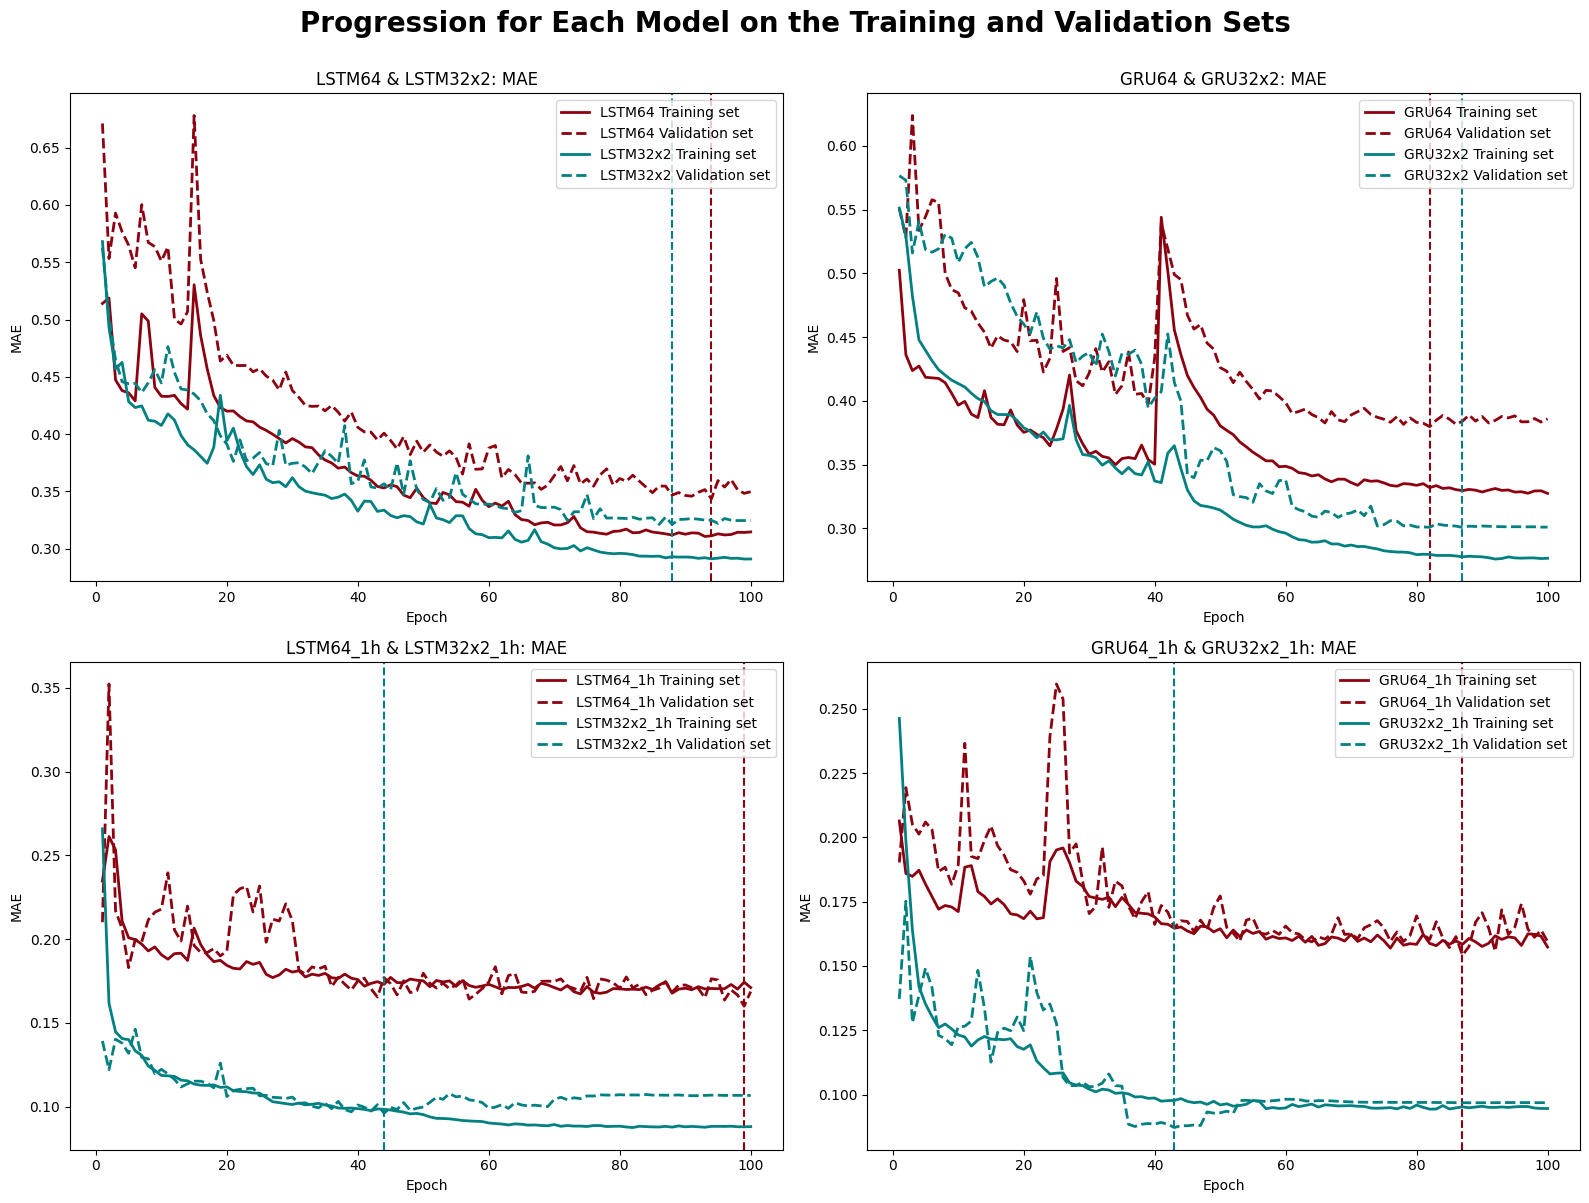

/kaggle/working/model_comparison.png

In [4]:
config = {
    "rows": 2,
    "cols": 2,
    "filename": "model_comparison.png",
    "min_val_mae_line_color": "#C0C0C0",
    "title": "Progression for Each Model on the Training and Validation Sets"
}

# Colors for LSTM and GRU
color_train_mae_1 = "#8C000F"   # Dark red for LSTM
color_val_mae_1   = "#8C000F"
color_train_mae_2 = "#008080"   # Teal for GRU
color_val_mae_2   = "#008080"

# Define models in the desired order
models = [
    "LSTM64", "GRU64",
    "LSTM32x2", "GRU32x2",
    "LSTM64_1h", "GRU64_1h",
    "LSTM32x2_1h", "GRU32x2_1h"
]

# Build paths and titles automatically
base = "/kaggle/input/lstm-models/"
history_paths = [
    f"{base}{ALL_MODELS[m]}/{ALL_MODELS[m]}_history.pkl" for m in models
]
model_titles = models[:]  # titles are just the model keys


history_dicts = [load_hist(p) for p in history_paths]

if any(h is None for h in history_dicts):
    print("At least one history file could not be loaded. Please check the paths.")
else:
    epochs = [range(1, len(h["loss"]) + 1) for h in history_dicts]

    # Model pairs as desired
    pairs = [
        (0, 2),  # LSTM64 vs LSTM32x2
        (1, 3),  # GRU64 vs GRU32x2
        (4, 6),  # LSTM64_1h vs LSTM32x2_1h
        (5, 7)   # GRU64_1h vs GRU32x2_1h
    ]

    plt.figure(figsize=(config["cols"]*8, config["rows"]*6))
    for i, (idx1, idx2) in enumerate(pairs):
        # Shared y-axis scaling for both models in one subplot
        min_mae = min(min(history_dicts[idx1]["mae"] + history_dicts[idx1]["val_mae"]),
                      min(history_dicts[idx2]["mae"] + history_dicts[idx2]["val_mae"]))
        max_mae = max(max(history_dicts[idx1]["mae"] + history_dicts[idx1]["val_mae"]),
                      max(history_dicts[idx2]["mae"] + history_dicts[idx2]["val_mae"]))
        margin = 0.05 * (max_mae - min_mae)
        min_mae -= margin
        max_mae += margin

        plt.subplot(config["rows"], config["cols"], i + 1)

        # Model 1
        val_mae_1 = history_dicts[idx1]["val_mae"]
        min_idx_1 = np.argmin(val_mae_1)
        min_epoch_1 = list(epochs[idx1])[min_idx_1]
        plt.plot(epochs[idx1], history_dicts[idx1]["mae"], "-", color=color_train_mae_1, linewidth=2, label=f"{model_titles[idx1]} Training set")
        plt.plot(epochs[idx1], val_mae_1, "--", color=color_val_mae_1, linewidth=2, label=f"{model_titles[idx1]} Validation set")
        plt.axvline(x=min_epoch_1, color=color_val_mae_1, linestyle='--')

        # Model 2
        val_mae_2 = history_dicts[idx2]["val_mae"]
        min_idx_2 = np.argmin(val_mae_2)
        min_epoch_2 = list(epochs[idx2])[min_idx_2]
        plt.plot(epochs[idx2], history_dicts[idx2]["mae"], "-", color=color_train_mae_2, linewidth=2, label=f"{model_titles[idx2]} Training set")
        plt.plot(epochs[idx2], val_mae_2, "--", color=color_val_mae_2, linewidth=2, label=f"{model_titles[idx2]} Validation set")
        plt.axvline(x=min_epoch_2, color=color_val_mae_2, linestyle='--')

        plt.title(f"{model_titles[idx1]} & {model_titles[idx2]}: MAE")
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.ylim(min_mae, max_mae)
        plt.legend(loc='upper right')

    plt.figtext(0.5, 0.98, config["title"], ha="center", fontsize=20, weight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(config["filename"], dpi=300, bbox_inches='tight')
    plt.show()
    display(FileLink(config["filename"]))


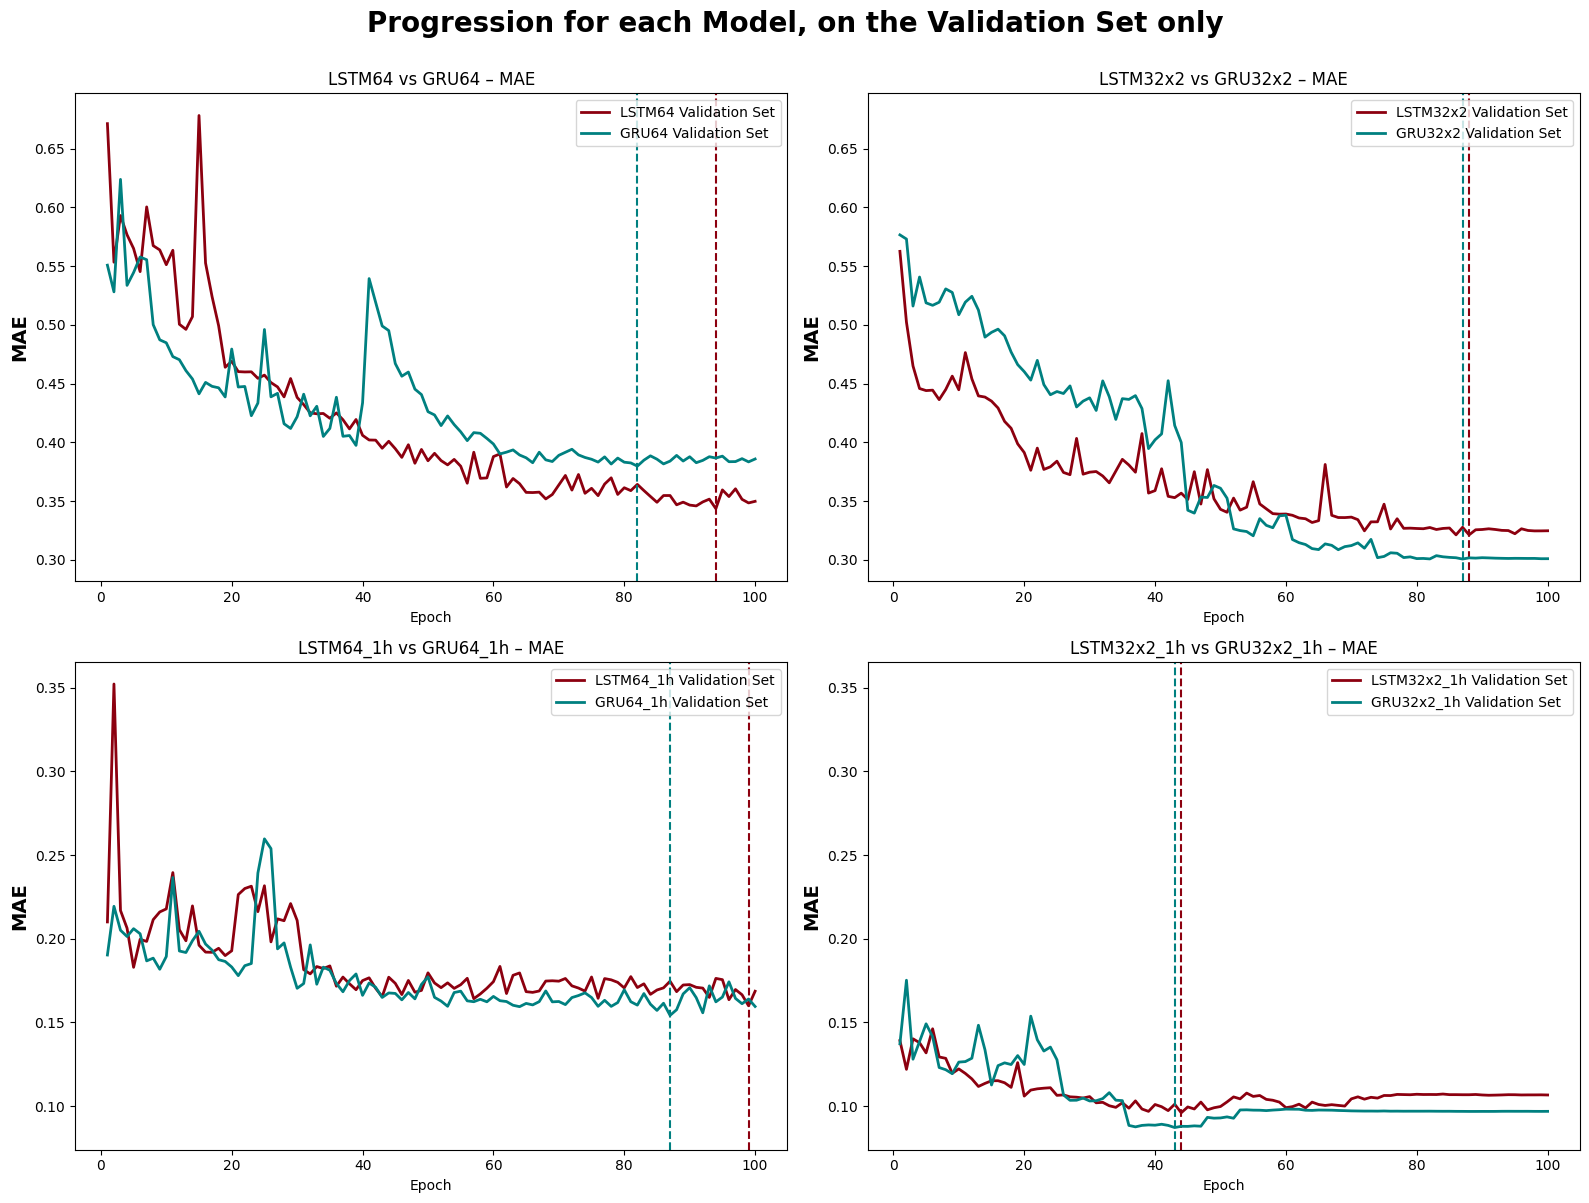

/kaggle/working/model_comparison.png

In [5]:
config = {
    "rows": 2,         
    "cols": 2,         
    "filename": "model_comparison.png",
    "title" : "Progression for each Model, on the Validation Set only"
}


models = [
    "LSTM64",  "GRU64",          # Plot 1
    "LSTM32x2","GRU32x2",        # Plot 2
    "LSTM64_1h","GRU64_1h",      # Plot 3
    "LSTM32x2_1h","GRU32x2_1h"   # Plot 4
]


plot_lstm_gru_comparison(models, config)


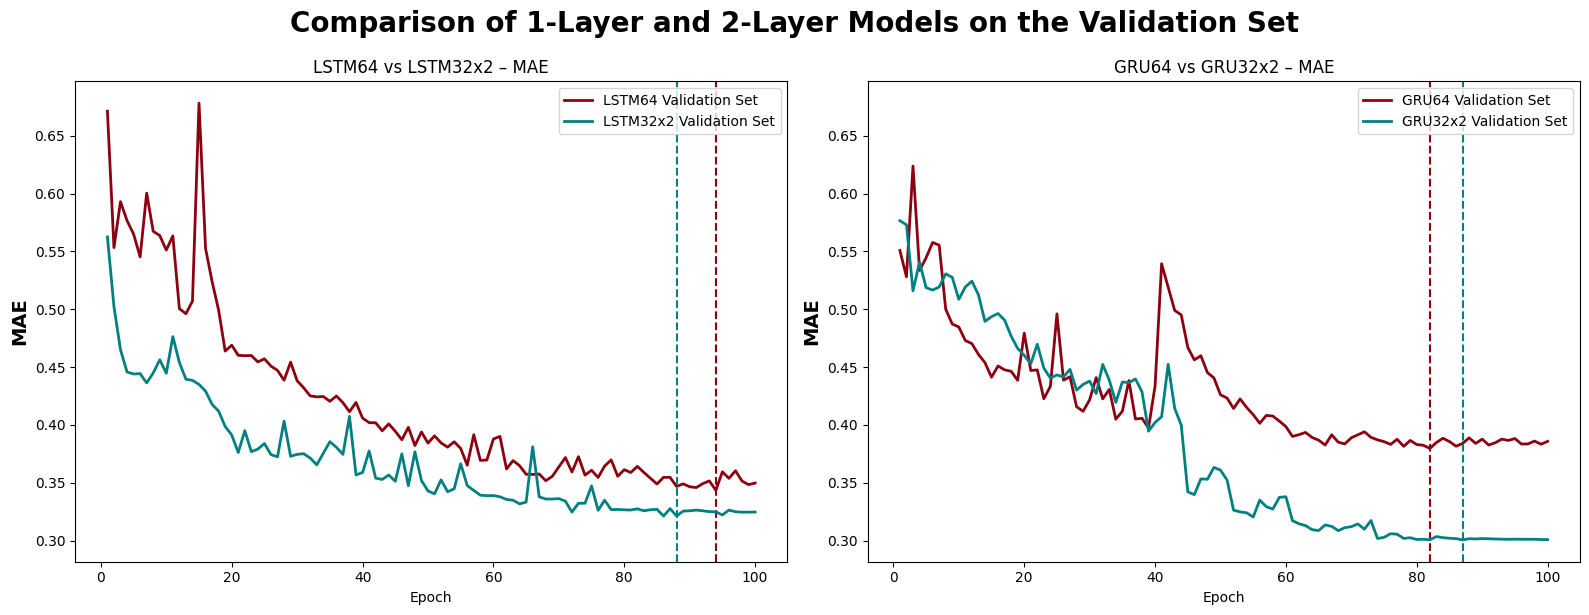

/kaggle/working/model_comparison_lstm_vs_gru.png

In [6]:
config = {
    "rows": 1,           
    "cols": 2,           
    "filename": "model_comparison_lstm_vs_gru.png",          
    "title": "Comparison of 1-Layer and 2-Layer Models on the Validation Set"}


models = [
    "LSTM64",  "LSTM32x2",
    "GRU64", "GRU32x2"]

plot_lstm_gru_comparison(models, config)


Model Comparison: LSTM vs GRU

|             Model              |     Epoch     |     Train MAE      |      Val MAE       |
|                                |   LSTM / GRU  |     LSTM / GRU     |     LSTM / GRU     |
|--------------------------------|---------------|--------------------|--------------------|
|        LSTM64 vs GRU64         |     94/82     |  0.3113 / 0.3319   |  0.3435 / 0.3797   |
|      LSTM32x2 vs GRU32x2       |     88/87     |  0.2931 / 0.2776   |  0.3212 / 0.3006   |
|                                |               |                    |                    |
|     LSTM64_1h vs GRU64_1h      |     99/87     |  0.1743 / 0.1584   |  0.1599 / 0.1542   |
|   LSTM32x2_1h vs GRU32x2_1h    |     44/43     |  0.0983 / 0.0977   |  0.0960 / 0.0871   |


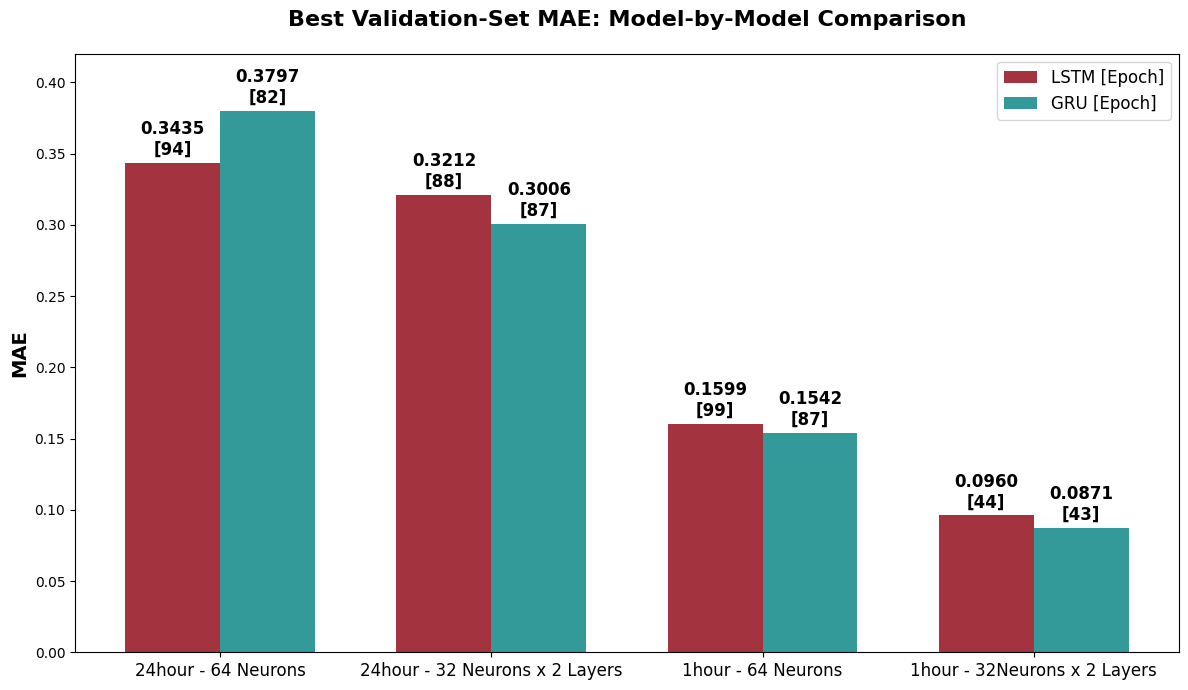

/kaggle/working/val_mae_comparison_single_plot.png

In [7]:
# ===== LOAD HISTORIES =====
hist_paths = {m: f"/kaggle/input/lstm-models/{d}/{d}_history.pkl" for m, d in ALL_MODELS.items()}

records = []
for name, pkl in hist_paths.items():
    h         = pickle.load(open(pkl, "rb"))
    v_mae     = h["val_mae"]
    t_mae     = h["mae"]
    best_idx  = v_mae.index(min(v_mae)) + 1
    records.append({
        "Model"      : name,
        "Best Epoch" : best_idx,
        "Train_MAE"  : f"{t_mae[best_idx-1]:.4f}",
        "Val_MAE"    : f"{min(v_mae):.4f}"
    })
df = pd.DataFrame(records)

# ===== PAIRWISE COMPARISON =====
MODEL_PAIRS = [
    ("LSTM64", "GRU64"),
    ("LSTM32x2", "GRU32x2"),
    ("LSTM64_1h", "GRU64_1h"),
    ("LSTM32x2_1h", "GRU32x2_1h")
]

rows = []
for a, b in MODEL_PAIRS:
    r1, r2 = df[df.Model == a].iloc[0], df[df.Model == b].iloc[0]
    rows.append({
        "Model"      : f"{a} / {b}",
        "Best Epoch" : f"{r1['Best Epoch']}/{r2['Best Epoch']}",
        "Train_MAE"  : f"{r1['Train_MAE']} / {r2['Train_MAE']}",
        "Val_MAE"    : f"{r1['Val_MAE']} / {r2['Val_MAE']}"
    })
cmp_df = pd.DataFrame(rows)

# ===== CONSOLE OUTPUT =====
w = {"Model":32, "Best Epoch":15, "Train_MAE":20, "Val_MAE":20}
print("Model Comparison: LSTM vs GRU\n")
print(f"|{'Model'.center(w['Model'])}|{'Epoch'.center(w['Best Epoch'])}|{'Train MAE'.center(w['Train_MAE'])}|{'Val MAE'.center(w['Val_MAE'])}|")
print(f"|{' '.center(w['Model'])}|{'LSTM / GRU'.center(w['Best Epoch'])}|{'LSTM / GRU'.center(w['Train_MAE'])}|{'LSTM / GRU'.center(w['Val_MAE'])}|")
print(f"|{'-'*w['Model']}|{'-'*w['Best Epoch']}|{'-'*w['Train_MAE']}|{'-'*w['Val_MAE']}|")
for i, (_, r) in enumerate(cmp_df.iterrows()):
    line = f"|{r['Model'].replace(' / ',' vs ').center(w['Model'])}|{r['Best Epoch'].center(w['Best Epoch'])}|{r['Train_MAE'].center(w['Train_MAE'])}|{r['Val_MAE'].center(w['Val_MAE'])}|"
    print(line)
    if i == 1:
        print(f"|{' '.center(w['Model'])}|{' '.center(w['Best Epoch'])}|{' '.center(w['Train_MAE'])}|{' '.center(w['Val_MAE'])}|")

# ===== CONFIGURATION FOR PLOT =====
config = {
    "x_axis_labels": [
        "24hour - 64 Neurons",       # LSTM64 vs GRU64
        "24hour - 32 Neurons x 2 Layers",     # LSTM32x2 vs GRU32x2  
        "1hour - 64 Neurons",        # 1Hour_LSTM64 vs 1Hour_GRU64
        "1hour - 32Neurons x 2 Layers"       # 1Hour_LSTM32x2 vs 1Hour_GRU32x2
    ],
    "y_axis_limits": (0, 0.42),
    "filename": "val_mae_comparison_single_plot.png"
}

# ===== DATA EXTRACTION FOR PLOT =====
val_mae_lstm = []
val_mae_gru = []
best_epoch_lstm = []
best_epoch_gru = []

for _, row in cmp_df.iterrows():
    val_lstm, val_gru = row['Val_MAE'].split(' / ')
    val_mae_lstm.append(float(val_lstm))
    val_mae_gru.append(float(val_gru))
    epoch_lstm, epoch_gru = row['Best Epoch'].split('/')
    best_epoch_lstm.append(epoch_lstm)
    best_epoch_gru.append(epoch_gru)

# ===== PLOTTING =====
x = np.arange(len(config["x_axis_labels"]))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, val_mae_lstm, width, label='LSTM [Epoch]', color='#8C000F', alpha=0.8)
bars2 = ax.bar(x + width/2, val_mae_gru, width, label='GRU [Epoch]', color='#008080', alpha=0.8)

ax.set_ylabel('MAE', fontsize=14, fontweight='bold')
ax.set_title('Best Validation-Set MAE: Model-by-Model Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(config["x_axis_labels"], rotation=0, ha='center', fontsize=12)
ax.legend(fontsize=12, loc='upper right')
ax.grid(False)

if config.get("y_axis_limits", None) is not None:
    ax.set_ylim(config["y_axis_limits"])

for bar, epoch in zip(bars1, best_epoch_lstm):
    height = bar.get_height()
    ax.annotate(f'{height:.4f}\n[{epoch}]',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=12, fontweight='bold')

for bar, epoch in zip(bars2, best_epoch_gru):
    height = bar.get_height()
    ax.annotate(f'{height:.4f}\n[{epoch}]',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(config["filename"], dpi=400, bbox_inches='tight')
plt.show()


display(FileLink(config["filename"]))
